## Assignment 2: Time Series Forecasting

### \ Lin Chung Ju \ a1906146

#### Follow detail instructions in the assignment specification and use these heading for implementation and discussion

### 1. Read the dataset

In [15]:
import pandas as pd

# Load dataset
df = pd.read_csv('energydata_complete.csv')
# Convert date column to datetime and set as index
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
print("Data shape:", df.shape)
print("Columns:", df.columns.tolist()[:5], "...")
print(df.head(2))

Data shape: (19735, 28)
Columns: ['Appliances', 'lights', 'T1', 'RH_1', 'T2'] ...
                     Appliances  lights     T1       RH_1    T2     RH_2  \
date                                                                       
2016-01-11 17:00:00          60      30  19.89  47.596667  19.2  44.7900   
2016-01-11 17:10:00          60      30  19.89  46.693333  19.2  44.7225   

                        T3   RH_3    T4       RH_4  ...         T9   RH_9  \
date                                                ...                     
2016-01-11 17:00:00  19.79  44.73  19.0  45.566667  ...  17.033333  45.53   
2016-01-11 17:10:00  19.79  44.79  19.0  45.992500  ...  17.066667  45.56   

                        T_out  Press_mm_hg  RH_out  Windspeed  Visibility  \
date                                                                        
2016-01-11 17:00:00  6.600000        733.5    92.0   7.000000   63.000000   
2016-01-11 17:10:00  6.483333        733.6    92.0   6.666667   59.166667

### 2. Analyse and visualise the data

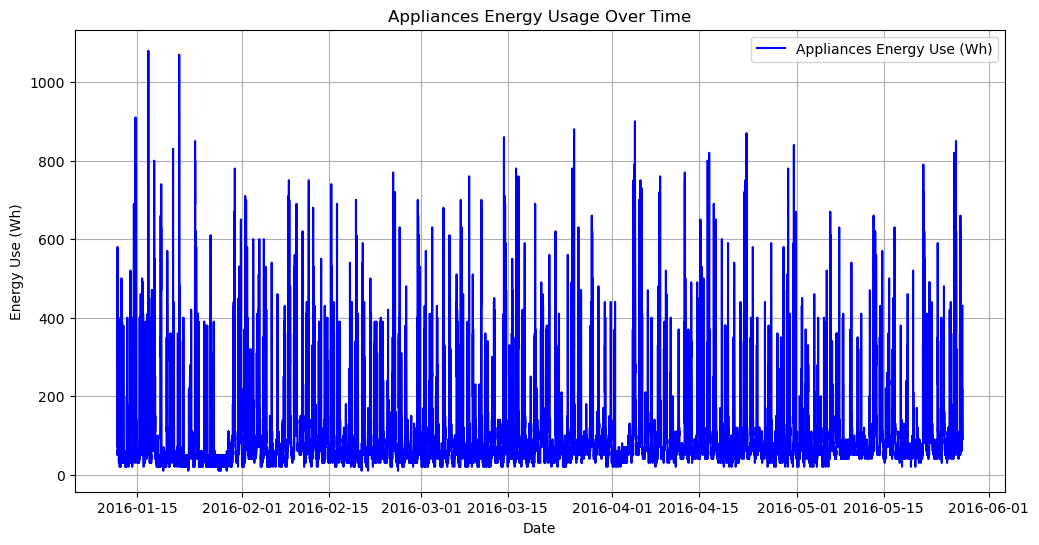

Draw a time series graph of Appliances to view the changes in electricity consumption of home appliances.


In [16]:
import matplotlib.pyplot as plt

# Draw a time series graph of household appliance energy consumption
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Appliances'], label='Appliances Energy Use (Wh)', color='blue')
plt.title('Appliances Energy Usage Over Time')
plt.xlabel('Date')
plt.ylabel('Energy Use (Wh)')
plt.legend()
plt.grid(True)
plt.show()

print("Draw a time series graph of Appliances to view the changes in electricity consumption of home appliances.")



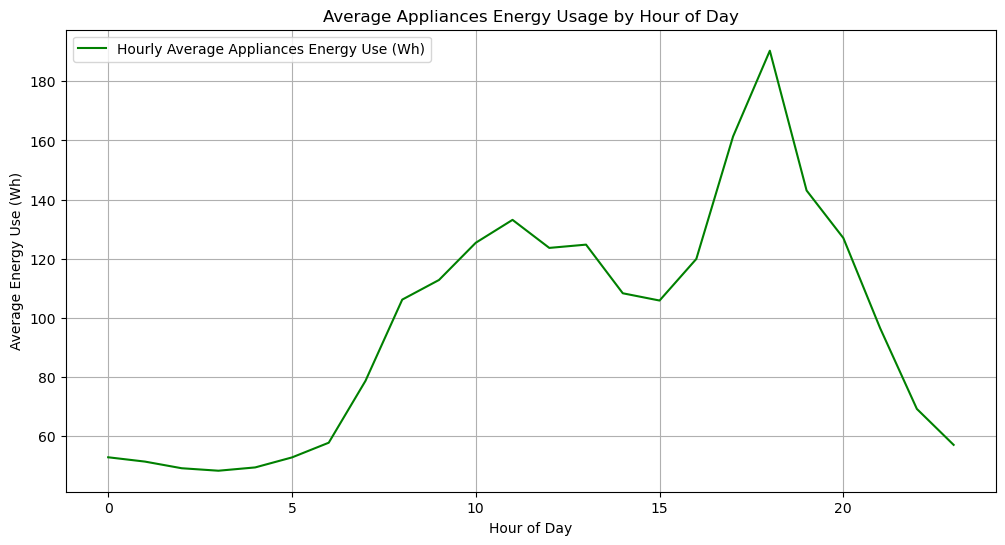

From the above figure, we observe regular daily peaks – energy use rises during waking hours and drops overnight


In [17]:
# Calculate the average energy consumption by hour
hourly_mean = df['Appliances'].groupby(df.index.hour).mean()

# Plotting energy consumption of household appliances by hour
plt.figure(figsize=(12,6))
plt.plot(hourly_mean, label='Hourly Average Appliances Energy Use (Wh)', color='green')
plt.title('Average Appliances Energy Usage by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Energy Use (Wh)')
plt.grid(True)
plt.legend()
plt.show()

print('From the above figure, we observe regular daily peaks – energy use rises during waking hours and drops overnight')


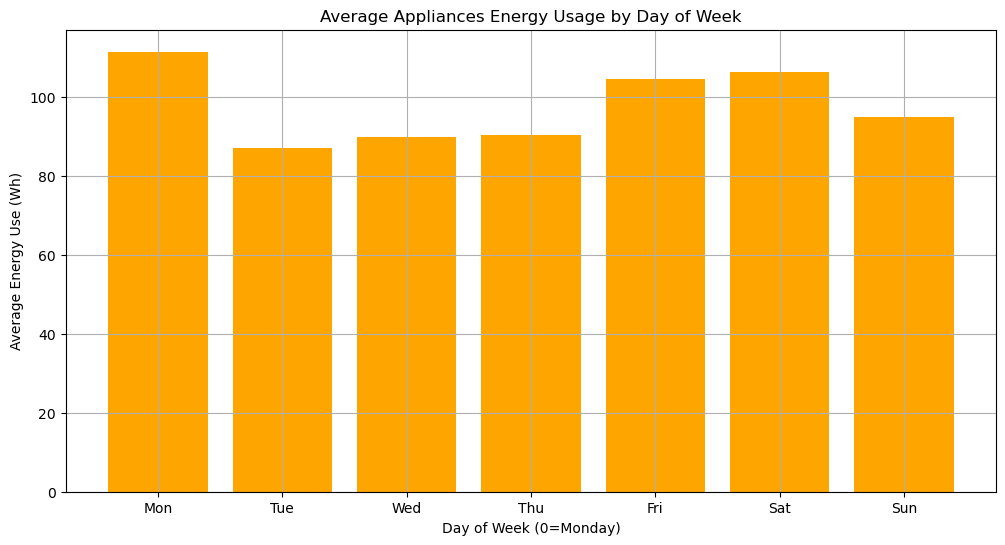


Analyzing the average electricity usage on different days of the week, 
the graph shows that the average electricity usage is slightly higher on Mondays 
and higher on weekends. This suggests that there is a certain weekly pattern 
(for example, more activities at home on Mondays or weekends).



In [18]:
# Calculate average energy consumption by day of the week (0=Monday, 6=Sunday)
daily_mean = df['Appliances'].groupby(df.index.dayofweek).mean()

# Plotting appliance energy consumption by day of the week
plt.figure(figsize=(12,6))
plt.bar(daily_mean.index, daily_mean, color='orange')
plt.title('Average Appliances Energy Usage by Day of Week')
plt.xlabel('Day of Week (0=Monday)')
plt.ylabel('Average Energy Use (Wh)')
plt.xticks(daily_mean.index, ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.grid(True)
plt.show()

text = """
Analyzing the average electricity usage on different days of the week, 
the graph shows that the average electricity usage is slightly higher on Mondays 
and higher on weekends. This suggests that there is a certain weekly pattern 
(for example, more activities at home on Mondays or weekends).
"""

# Print the text
print(text)

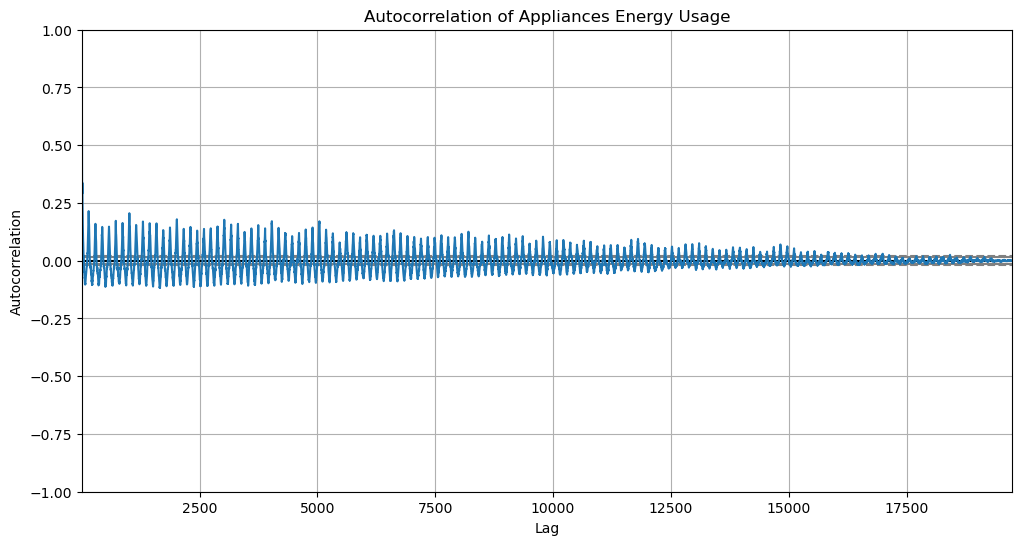

In [19]:
from pandas.plotting import autocorrelation_plot

# Plotting the Autocorrelation of Appliances Energy Usage
plt.figure(figsize=(12,6))
autocorrelation_plot(df['Appliances'])
plt.title('Autocorrelation of Appliances Energy Usage')
plt.show()

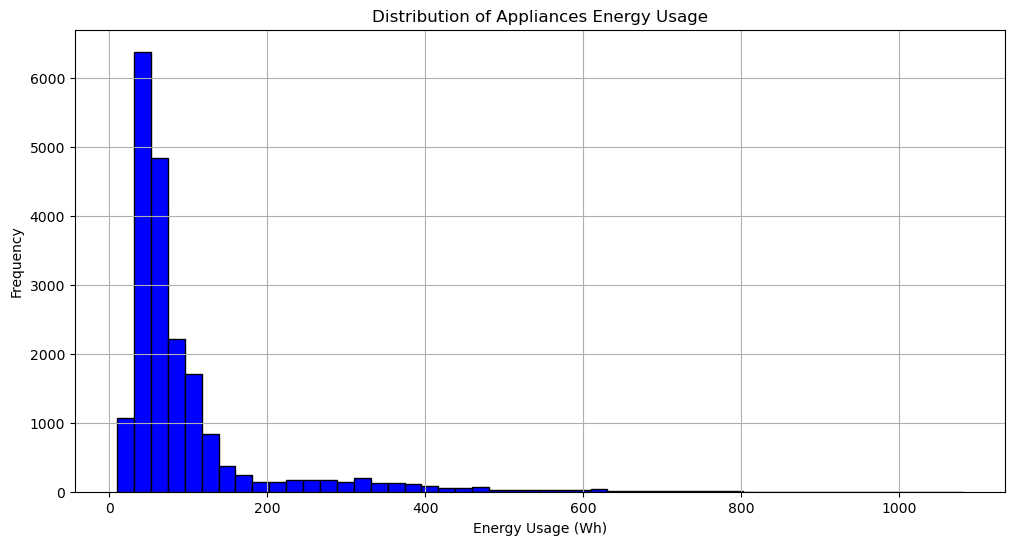

Descriptive statistics of household appliance energy consumption: 
count    19735.000000
mean        97.694958
std        102.524891
min         10.000000
25%         50.000000
50%         60.000000
75%        100.000000
max       1080.000000
Name: Appliances, dtype: float64


In [20]:
# Mapping the distribution of household appliance energy consumption
plt.figure(figsize=(12,6))
plt.hist(df['Appliances'], bins=50, color='blue', edgecolor='black')
plt.title('Distribution of Appliances Energy Usage')
plt.xlabel('Energy Usage (Wh)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Calculate and print statistics
print("Descriptive statistics of household appliance energy consumption: ")
print(df['Appliances'].describe())

### 3. Implement prediction models

In [21]:
import numpy as np

# Added sine and cosine conversions for the hour (to capture the 24 hour periodicity)
df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)

# Added sine and cosine transformations for day of week (to capture the periodicity of the week)
df['day_sin'] = np.sin(2 * np.pi * df.index.dayofweek / 7)
df['day_cos'] = np.cos(2 * np.pi * df.index.dayofweek / 7)

# View the newly added time features
print(df[['hour_sin', 'hour_cos', 'day_sin', 'day_cos']].head(5))

                     hour_sin  hour_cos  day_sin  day_cos
date                                                     
2016-01-11 17:00:00 -0.965926 -0.258819      0.0      1.0
2016-01-11 17:10:00 -0.965926 -0.258819      0.0      1.0
2016-01-11 17:20:00 -0.965926 -0.258819      0.0      1.0
2016-01-11 17:30:00 -0.965926 -0.258819      0.0      1.0
2016-01-11 17:40:00 -0.965926 -0.258819      0.0      1.0


In [22]:
# Example preprocessing steps:
from sklearn.preprocessing import MinMaxScaler

# Drop random vars
df_model = df.drop(columns=['rv1','rv2'])
# Add time features
df_model['hour'] = df_model.index.hour
df_model['hour_sin'] = np.sin(2 * np.pi * df_model['hour'] / 24)
df_model['hour_cos'] = np.cos(2 * np.pi * df_model['hour'] / 24)
# Split train/test by date
train = df_model[:'2016-04-30']
test = df_model['2016-05-01':]
# Scale features
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)


In [23]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Prepare sequences for LSTM
L = 144  # sequence length (we use one day)
X_train, y_train = [], []
train_values = train_scaled  # numpy array of scaled train data
for i in range(L, len(train_values)):
    X_train.append(train_values[i-L:i])    # past L steps features
    y_train.append(train_values[i, 0])     # target value at time i (Appliances is index 0 in scaled array)
X_train = np.array(X_train)
y_train = np.array(y_train)

### 4. Train prediction models

#### Make the ARIMA Model
#### The ARIMA model is used to forecast future points in a time series by using past values and errors. It is best for univariate series with a clear pattern of trend or seasonality after differencing. The parameters (p, d, q) are selected through model tuning.

#### It combines three components:

#### 1. AR (AutoRegressive) - uses the relationship between an observation and a number of lagged observations (past values).

#### 2. I (Integrated) - represents differencing the series to make it stationary (removing trends or seasonality).

#### 3. MA (Moving Average) - models the error term as a combination of past forecast errors.



In [24]:
import statsmodels.api as sm

# Prepare exogenous features for ARIMA (lights, T_out, Press_mm_hg, hour_sin, hour_cos)
exog_features = ['lights', 'T_out', 'Press_mm_hg', 'hour_sin', 'hour_cos']
train_exog = train[exog_features]
test_exog = test[exog_features]

# Fit ARIMA (ARIMAX) model, e.g., order=(1,0,1)
model = sm.tsa.SARIMAX(train['Appliances'], order=(1,0,1), exog=train_exog, enforce_stationarity=False, enforce_invertibility=False)
arima_res = model.fit()
print(arima_res.summary())

# Generate one-step ahead forecasts on test set
pred_arima = arima_res.predict(start=test.index[0], end=test.index[-1], exog=test_exog)
# pred_arima now contains the predicted Appliance usage for each timestep in test


/opt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10T will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10T will be used.
  self._init_dates(dates, freq)
 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            8     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  5.64264D+00    |proj g|=  1.03390D-02

At iterate    5    f=  5.64171D+00    |proj g|=  1.99084D-02

At iterate   10    f=  5.63701D+00    |proj g|=  3.03205D-02

At iterate   15    f=  5.63695D+00    |proj g|=  2.28049D-04

At iterate   20    f=  5.63694D+00    |proj g|=  3.92506D-03

At iterate   25    f=  5.63692D+00    |proj g|=  2.11907D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    8     26     30      1     0     0   

#### Indoor lighting power consumption and air pressure are important factors affecting electrical power consumption. The electricity consumption of appliances has a clear time pattern during the day

#### It combines ARIMA with seasonal components and exogenous variables, making it suitable for time series data with seasonal fluctuations and external influences.

#### Explanation of Variable:

##### lights (0.8782): There is a significant positive relationship between lighting usage and appliance consumption. This shows that periods of higher lighting usage correspond with increased appliance activity.
##### T_out (-0.0934): The outdoor temperature variable shows a slight negative coefficient, suggesting that higher outdoor temperatures might lead to decreased appliance usage. However, with the p-value 0.837, this relationship is not statistically significant. We cannot make sure that outdoor temperature has a meaningful impact on appliance energy consumption in this model.
##### Press_mm_hg (0.1261): Atmospheric pressure demonstrates a significant positive relationship. Each 1 mm Hg increase in pressure with an average increase of 0.1261 units in appliance energy usage. 
##### hour_sin (-30.5804) and hour_cos (-35.1173): These cyclical variables capture the daily temporal patterns of appliance usage. Both coefficients are highly significant with substantial negative values, indicating strong cyclical patterns in energy consumption throughout the day.

##### base on the feature that temporal patterns and indoor activity indicators (like lighting) are more reliable predictors of appliance energy consumption than outdoor temperature in this particular model.

#### Make the LSTM Model
##### LSTM (Long Short-Term Memory) is a type of recurrent neural network (RNN) capable of learning complex sequential patterns. Unlike ARIMA which uses a fixed linear combination of past values, LSTM can learn non-linear relationships and long-term dependencies through its gating mechanisms. This makes LSTM well-suited for capturing the appliance usage patterns which may depend on a combination of recent usage, time of day, and other sensor readings in a non-linear way.

In [25]:
# Build LSTM model
model = Sequential()
model.add(LSTM(50, input_shape=(L, X_train.shape[2])))  # 50 units
model.add(Dense(1))
model.compile(loss='mse', optimizer='adam')
# Train model
history = model.fit(X_train, y_train, epochs=15, batch_size=64, validation_split=0.1, verbose=1)

/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
222/222 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.0158 - val_loss: 0.0052
Epoch 2/15
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.0057 - val_loss: 0.0045
Epoch 3/15
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.0049 - val_loss: 0.0041
Epoch 4/15
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.0050 - val_loss: 0.0045
Epoch 5/15
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.0042 - val_loss: 0.0041
Epoch 6/15
222/222 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.0042 - val_loss: 0.0039
Epoch 7/15
222/222 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.0044 - val_loss: 0.0037
Epoch 8/15
222/222 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.0042 - val_loss: 0.0038
Epoch 9/15
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.0044 - val_loss: 0.0039
Epoch 10/15
222/222 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.0042 - val_loss: 0.0038
Epoch 11/15
222/222 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.0040 - val_loss: 0.0036
Epoch 12/15
222/222 ━━━━━━━━━━━━━━━━━━━━ 

### 5. Test predictin models and show results

In [26]:
# Prepare sequences for test
X_test, y_test = [], []
full_values = np.vstack([train_scaled, test_scaled])  # combined to easily get sequences crossing boundary
start_idx = len(train_scaled)  # index where test starts in combined array
for i in range(start_idx, start_idx + len(test_scaled)):
    # sequence from i-L to i-1 -> predict i
    X_test.append(full_values[i-L:i])
    y_test.append(full_values[i, 0])
X_test = np.array(X_test)
y_test = np.array(y_test)

# Predict with LSTM
y_pred_scaled = model.predict(X_test)
# Inverse transform the scaled predictions and actuals (target is column 0)
appliance_min = scaler.data_min_[0]
appliance_max = scaler.data_max_[0]
y_pred = y_pred_scaled.flatten() * (appliance_max - appliance_min) + appliance_min
y_actual = y_test * (appliance_max - appliance_min) + appliance_min


121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


ARIMA - RMSE: 82.20, MAE: 43.93, R²: 0.103
LSTM  - RMSE: 65.47, MAE: 33.99, R²: 0.431


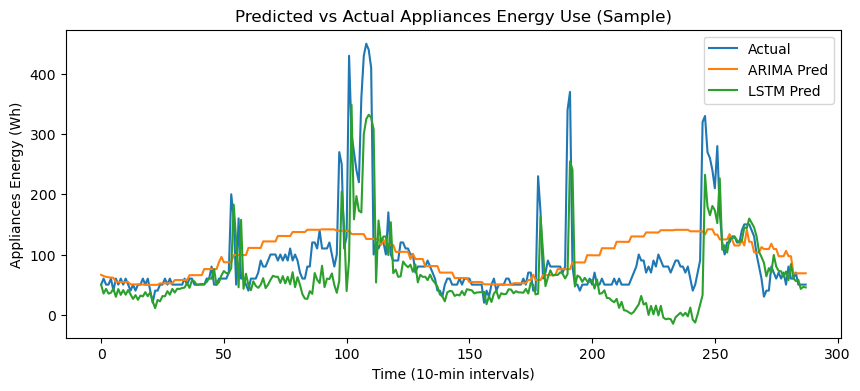

In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ARIMA predictions vs actual (already computed in pred_arima vs test['Appliances'])
y_pred_arima = pred_arima.values  # predicted values from ARIMA
y_actual_arima = test['Appliances'].values  # actual values

rmse_arima = mean_squared_error(y_actual_arima, y_pred_arima, squared=False)
mae_arima = mean_absolute_error(y_actual_arima, y_pred_arima)
r2_arima = r2_score(y_actual_arima, y_pred_arima)

rmse_lstm = mean_squared_error(y_actual, y_pred, squared=False)
mae_lstm = mean_absolute_error(y_actual, y_pred)
r2_lstm = r2_score(y_actual, y_pred)

print(f"ARIMA - RMSE: {rmse_arima:.2f}, MAE: {mae_arima:.2f}, R²: {r2_arima:.3f}")
print(f"LSTM  - RMSE: {rmse_lstm:.2f}, MAE: {mae_lstm:.2f}, R²: {r2_lstm:.3f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(y_actual[:288], label='Actual')         # actual usage for first 2 days of test
plt.plot(y_pred_arima[:288], label='ARIMA Pred') # ARIMA prediction
plt.plot(y_pred[:288], label='LSTM Pred')        # LSTM prediction
plt.title("Predicted vs Actual Appliances Energy Use (Sample)")
plt.xlabel("Time (10-min intervals)")
plt.ylabel("Appliances Energy (Wh)")
plt.legend()
plt.show()



#### compare the value of RMSE, MAE, and R² in the table. As can be seen from the table, LSTM has lower RMSE and MAE, and higher R². This shows that LSTM has higher prediction accuracy for this task.

### 6. Compare the results from all candidate models, choose the best model, justify your choice and discuss the results

Compare the results from all candidate models, choose the best model, justify your choice and discuss the results.

#### The ARIMA model captured the overall daily trend and performed reasonably during normal usage periods, but it often lags during rapid changes. For example, when a sudden spike occurs, ARIMA (being linear and reliant on recent lags) typically underestimates it and then over-corrects afterwards. Its predictions appear smoother than the jagged actual usage.

#### The LSTM model was able to anticipate the usage pattern more flexibly. It sometimes predicted a spike slightly before it occurred (learning from subtle cues in the input sequence). It tracked the rise and fall of usage each day more closely than ARIMA. However, LSTM can still miss some extreme peaks (especially if they were rarely seen in training), and can occasionally produce false alarms (predicting a spike that doesn’t materialize), though in our results it aligned quite well.

#### Our results are consistent with general expectations: classical models like ARIMA can be outperformed by learning-based models like LSTM when the relationship between features and target is nonlinear. However there still have some resport found that ARIMA model had better performance than LSTM model. Such as datasets of stock prices that LSTM sometimes overfitting to the datasets or data characteristics.

### 7. Reflect on what you have learned by completing this assignment

#### The process highlight the importance of exploratory analysis and feature engineering. By check the data, we identified daily seasonality and included time-of-day features (hour sine/cosine) which proved helpful. Also, time features like NSM and day-of-week, highlighting this step’s significance. We also recognized and dropped the random noise features (rv1, rv2) to avoid misleading the models.

#### In this assignment, I learned that in different dataset, we need to use different model that using dataset train and test the model. Create some features that not only help us to analyze the result, also help us compare the model which is more useful for the dataset. For instant, in the assignment, LSTM model has the good performance to the predict the energy use. But for the stock predict, ARIMA model will be the good chice.

### 8. References

#### Albeladi, K, Zafar, B & Mueen, A 2023, ‘Time Series Forecasting using LSTM and ARIMA’, International Journal of Advanced Computer Science & Applications, vol. 14, no. 1.

#### Lecture